### Exploratory Data Analysis (EDA)

#### Objective

The objective of this notebook is to explore customer characteristics and identify the key factors associated with customer value in the ISP business.

The analysis focuses on revenue distribution, high-value customer profiling, and relationships between important business features.

The insights obtained from this notebook will be used to design a business-oriented Customer Priority Score and support the subsequent customer prioritization model.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

%matplotlib inline

### Load Cleaned Dataset

The cleaned dataset generated in the previous notebook is loaded for exploratory analysis.

In [2]:
df = pd.read_csv("../data/cleaned_isp_customers.csv")

In [3]:
df.head()

,Customer_ID,Bandwidth_Mbps,Price_Per_Mbps,Monthly_Internet_Fee,Years_With_Company,Customer_Type,Company_Size,Strategic_Category,Strategic_Level,Has_VoIP,Monthly_VoIP_Fee,Has_Server,Server_Type,Monthly_Server_Fee,Support_Tickets_Last_Year,Downtime_Hours_Last_Year,Contract_Type
0,C00001,10,320000,3200000,4.2,Personal,Small,Normal,0,0,0.0,0,NaN,0.0,0,4.8,Monthly
1,C00002,10,385000,3850000,1.5,Personal,Small,Normal,0,0,0.0,0,NaN,0.0,3,4.8,Monthly
2,C00003,20,335000,6700000,0.9,Personal,Small,Normal,0,0,0.0,0,NaN,0.0,3,5.6,Monthly
3,C00004,50,315000,15750000,3.1,Personal,Small,Normal,0,0,0.0,0,NaN,0.0,2,1.3,Monthly
4,C00005,30,350000,10500000,2.2,Personal,Small,Normal,0,0,0.0,0,NaN,0.0,5,6.3,Monthly


### 1. Total Monthly Revenue

#### Objective

Customers may subscribe to multiple services such as Internet, VoIP, and Server hosting.

To better estimate the business value of each customer, a new feature representing the total monthly revenue is created.

In [4]:
df["Total_Monthly_Revenue"] = (
    df["Monthly_Internet_Fee"]
    + df["Monthly_VoIP_Fee"]
    + df["Monthly_Server_Fee"]
)
df["Total_Monthly_Revenue"]

0        3200000.0
1        3850000.0
2        6700000.0
3       15750000.0
4       10500000.0
           ...    
2995     9000000.0
2996     7000000.0
2997     5225504.0
2998    40011908.0
2999     6100000.0
Name: Total_Monthly_Revenue, Length: 3000, dtype: float64

#### 1.1  Identifying High-Value Customers

#### Objective

This section analyzes the distribution of customer revenue and determines a suitable threshold for identifying high-value customers.

In [5]:
df["Total_Monthly_Revenue"].describe()

count    3.000000e+03
mean     2.316773e+07
std      2.202715e+07
min      3.200000e+06
25%      6.000000e+06
50%      1.350000e+07
75%      3.900000e+07
max      1.443483e+08
Name: Total_Monthly_Revenue, dtype: float64

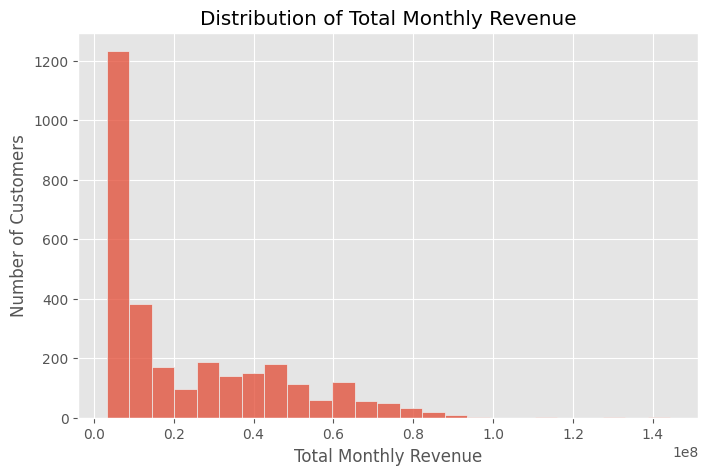

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Total_Monthly_Revenue",
    bins=25
)

plt.title("Distribution of Total Monthly Revenue")
plt.xlabel("Total Monthly Revenue")
plt.ylabel("Number of Customers")

plt.show()

In [7]:
df["Total_Monthly_Revenue"].quantile(
    [0.50, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99]
)

0.50    13500000.00
0.75    39000000.00
0.80    44000000.00
0.85    49379037.75
0.90    58881739.70
0.95    67394838.40
0.99    82488945.07
Name: Total_Monthly_Revenue, dtype: float64

### Threshold Selection
Based on the revenue distribution and percentile analysis, customers in the top 20% of total monthly revenue were selected as **High-Value Customers**.


In [8]:
df["Number_of_Services"] = (
    1
    + df["Has_VoIP"]
    + df["Has_Server"]
)

In [9]:
threshold = df["Total_Monthly_Revenue"].quantile(0.80)
high_value = df[
    df["Total_Monthly_Revenue"] >= threshold
]

df["High_Value"] = (
    df["Total_Monthly_Revenue"] >= threshold
).astype(int)

df["High_Value"].value_counts()



print(f"Revenue Threshold: {threshold:,.0f} Toman")
print(f"Number of High-Value Customers: {len(high_value)}")

Revenue Threshold: 44,000,000 Toman
Number of High-Value Customers: 619


In [10]:
print(f"High-value customers: {len(high_value)}")
print(f"Percentage of all customers: {len(high_value) / len(df) * 100:.1f}%")

High-value customers: 619
Percentage of all customers: 20.6%



### 2. High-Value Customer Analysis

#### Business Questions

- Which customer types dominate the high-value segment?
- What characteristics distinguish high-value customers?

#### 2.1 Customer Type Distribution

In [11]:
overall_customer_type = (
    df["Customer_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

overall_customer_type

Customer_Type
Personal      49.6
Business      41.7
Government     8.7
Name: proportion, dtype: float64

In [12]:
high_value_customer_type = (
    high_value["Customer_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

high_value_customer_type

Customer_Type
Business      70.3
Government    29.7
Name: proportion, dtype: float64

In [13]:
comparison = pd.DataFrame({
    "Overall (%)": overall_customer_type,
    "High-Value (%)": high_value_customer_type
}).fillna(0)

comparison

,Overall (%),High-Value (%)
Customer_Type,,
Business,41.7,70.3
Government,8.7,29.7
Personal,49.6,0.0





### Observation

Business customers account for **41.7%** of the overall customer population but represent **70.3%** of high-value customers.

Government customers increase from **8.7%** of the overall population to **29.7%** of the high-value segment.

No Personal customers appear among the identified high-value customers.



### Business Recommendation

Marketing campaigns should prioritize Business and Government organizations, as these customer segments show a much higher likelihood of becoming high-value customers.

Sales teams may also prioritize these organizations when promoting premium Internet, VoIP, and Server solutions.

#### 2.2 High-Value Customer Profile

##### Objective

The following analysis focuses on identifying the characteristics of high-value Business and Government customers.

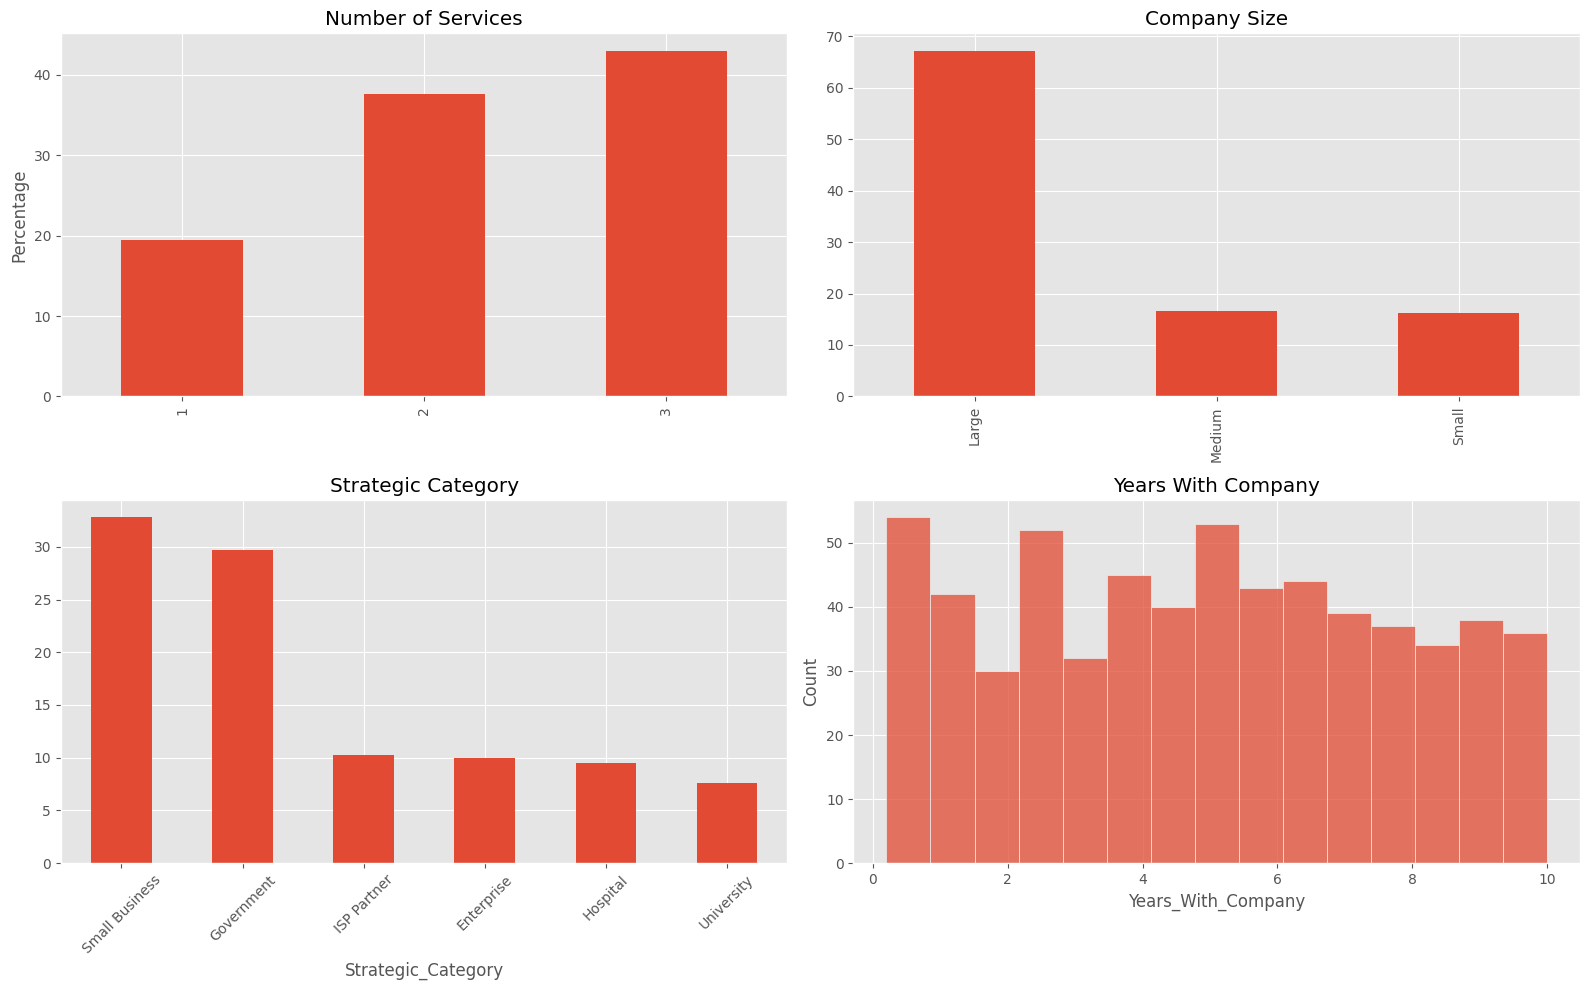

Number of Services (%)
Number_of_Services
1    19.4
2    37.6
3    43.0
Name: proportion, dtype: float64

Company Size (%)
Company_Size
Large     67.2
Medium    16.6
Small     16.2
Name: proportion, dtype: float64

Strategic Category (%)
Strategic_Category
Small Business    32.8
Government        29.7
ISP Partner       10.3
Enterprise        10.0
Hospital           9.5
University         7.6
Name: proportion, dtype: float64

Years With Company
count    619.000000
mean       4.921648
std        2.794143
min        0.200000
25%        2.500000
50%        5.000000
75%        7.200000
max       10.000000
Name: Years_With_Company, dtype: float64


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Number of Services
services = (
     high_value["Number_of_Services"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

services.plot(kind="bar", ax=axes[0,0])
axes[0,0].set_title("Number of Services")
axes[0,0].set_xlabel("")
axes[0,0].set_ylabel("Percentage")

# Company Size
company_size = (
    high_value["Company_Size"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

company_size.sort_index().plot(kind="bar", ax=axes[0,1])
axes[0,1].set_title("Company Size")
axes[0,1].set_xlabel("")

# Strategic Category
strategic = (
    high_value["Strategic_Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

strategic.plot(kind="bar", ax=axes[1,0])
axes[1,0].set_title("Strategic Category")
axes[1,0].tick_params(axis="x", rotation=45)

# Years With Company
sns.histplot(
    high_value["Years_With_Company"],
    bins=15,
    ax=axes[1,1]
)

axes[1,1].set_title("Years With Company")

plt.tight_layout()

plt.show()

print("Number of Services (%)")
print(services)

print("\nCompany Size (%)")
print(company_size)

print("\nStrategic Category (%)")
print(strategic)

print("\nYears With Company")
print(high_value["Years_With_Company"].describe())

### Observation

The analysis reveals several common characteristics among high-value customers:

- Approximately 80% of high-value customers subscribe to two or three ISP services, while customers with only one service represent a much smaller proportion.
- Around two-thirds of high-value customers are large companies, whereas medium and small companies account for a considerably smaller share.
- The largest strategic customer groups are Small Business and Government, together representing more than half of all high-value customers.
- High-value customers are distributed across different customer tenures, with no clear concentration in a specific range of years.

### Business Insight

These characteristics indicate that high-value customers are primarily large organizations that purchase multiple services and belong to strategically important customer groups.

These findings will be incorporated into the Customer Priority Score in the next notebook.

#### 3. Correlation Analysis

### Objective

Correlation analysis is performed to explore the relationships between numerical features in the dataset.

Understanding these relationships helps identify the variables most strongly associated with customer value and provides useful insights for designing the Customer Priority Score.

In [15]:
numeric = [
    "Bandwidth_Mbps",
    "Monthly_Internet_Fee",
    "Monthly_Server_Fee",
    "Monthly_VoIP_Fee",
    "Years_With_Company",
    "Support_Tickets_Last_Year",
    "Downtime_Hours_Last_Year",
    "Strategic_Level",
    "Total_Monthly_Revenue"
]

corr = df[numeric].corr(numeric_only=True)

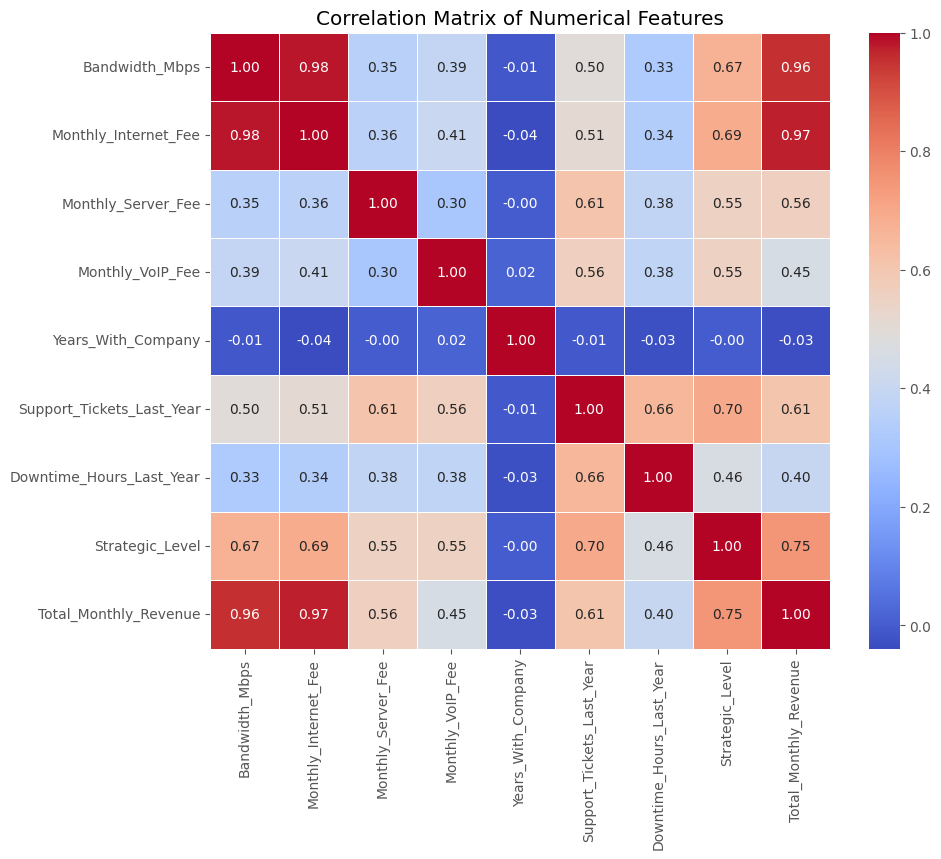

In [16]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

### Key Findings

The correlation analysis highlights several important relationships among the numerical features.

- Total monthly revenue has a strong positive correlation with **Strategic Level** (0.75), indicating that strategically important customers tend to generate higher revenue.
- **Years With Company** shows almost no correlation with revenue (-0.03), suggesting that customer value is not strongly related to customer tenure.
- Revenue is also highly correlated with **Bandwidth** and **Monthly Internet Fee**. This is expected because Internet revenue is directly determined by the customer's subscribed bandwidth and pricing model.

These findings reinforce that customer value is primarily associated with service usage and strategic importance rather than the length of the customer relationship.

### 4. EDA Summary

#### Key Findings

The exploratory data analysis provided several important insights into customer value within the ISP business.

- High-value customers were identified as the top 20% of customers based on total monthly revenue.
- Business and Government organizations dominate the high-value customer segment, while Personal customers are absent.
- High-value customers typically subscribe to multiple ISP services and are more frequently associated with large companies and strategic customer categories.
- Correlation analysis indicates that customer value is strongly associated with service usage and strategic importance, while customer tenure shows little relationship with revenue.

### Conclusion

The EDA identified the main characteristics of high-value customers and the factors associated with customer value.

These findings provide the foundation for the next stage of the project, where a Customer Priority Score will be designed to rank customers according to their business value.


In [17]:
df.to_csv("../data/clean_isp_customers.csv", index=False)

print("Clean dataset saved successfully.")
print(df.columns.tolist())

Clean dataset saved successfully.
['Customer_ID', 'Bandwidth_Mbps', 'Price_Per_Mbps', 'Monthly_Internet_Fee', 'Years_With_Company', 'Customer_Type', 'Company_Size', 'Strategic_Category', 'Strategic_Level', 'Has_VoIP', 'Monthly_VoIP_Fee', 'Has_Server', 'Server_Type', 'Monthly_Server_Fee', 'Support_Tickets_Last_Year', 'Downtime_Hours_Last_Year', 'Contract_Type', 'Total_Monthly_Revenue', 'Number_of_Services', 'High_Value']


In [18]:
df.to_csv("../data/clean_isp_customers.csv", index=False)